<a href="https://colab.research.google.com/github/farahrhma/latihanutsdatmin/blob/main/cobauts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latihan UTS DATA MINING - STUDENT PERFORMANCE

IMPORT LIBRARY

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, r2_score

LOAD DATA

In [19]:
df = pd.read_csv('student_data.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [20]:
df['performa'] = df['G3'].apply(lambda x: 'Baik' if x >= 10 else 'Tidak Baik')

EDA (VISUALISASI)

In [26]:
print(df['performa'].value_counts())

performa
Baik          265
Tidak Baik    130
Name: count, dtype: int64


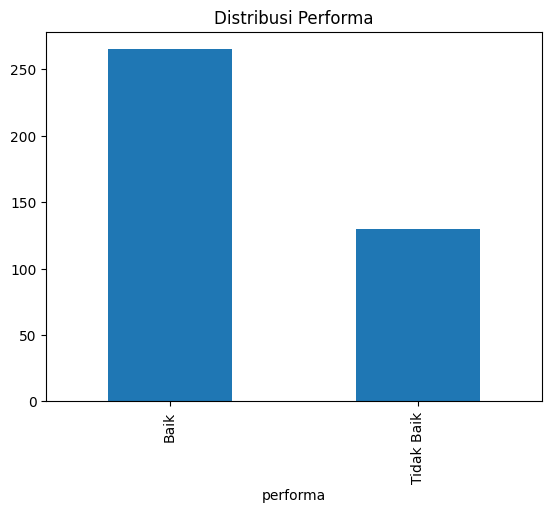

In [27]:
df['performa'].value_counts().plot(kind='bar')
plt.title("Distribusi Performa")
plt.show()

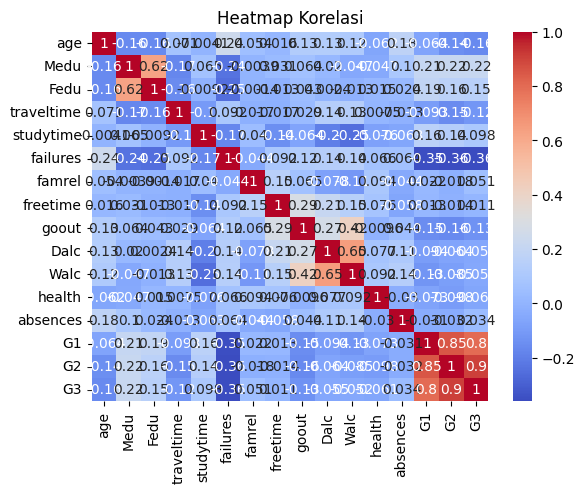

In [28]:
# Korelasi
num_cols = df.select_dtypes(include=np.number)
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi")
plt.show()

PREPROCESSING

In [29]:
# Drop G3 biar gak bocor (karena itu target asli)
X = df.drop(['performa', 'G3'], axis=1)
y = df['performa']

In [30]:
# Encoding semua kategori
le_dict = {}
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

In [31]:
# Encoding Y
le_y = LabelEncoder()
y = le_y.fit_transform(y)

In [32]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

CLUSTERING (K-MEANS)

In [34]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [36]:
df['cluster'] = clusters
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,performa,cluster
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,6,5,6,6,Tidak Baik,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,4,5,5,6,Tidak Baik,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,10,7,8,10,Baik,0
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,2,15,14,15,Baik,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,4,6,10,10,Baik,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,4,4,5,4,11,9,9,9,Tidak Baik,0
391,MS,M,17,U,LE3,T,3,1,services,services,...,5,3,4,2,3,14,16,16,Baik,0
392,MS,M,21,R,GT3,T,1,1,other,other,...,3,3,3,3,3,10,8,7,Tidak Baik,0
393,MS,M,18,R,LE3,T,3,2,services,other,...,1,3,4,5,0,11,12,10,Baik,0


In [37]:
print(pd.Series(clusters).value_counts())

1    239
0    156
Name: count, dtype: int64


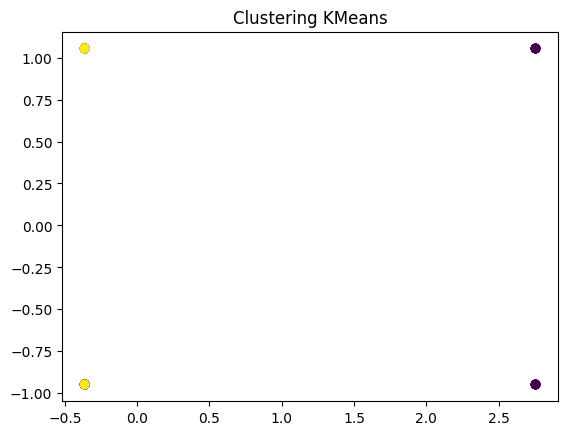

In [38]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.title("Clustering KMeans")
plt.show()

KLASIFIKASI

In [39]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [41]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'KNN': KNeighborsClassifier()
}
results = {}

In [42]:
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_val, model.predict(X_val))
    results[name] = {'model': model, 'acc': acc}
    print(f"{name}: {acc*100:.2f}%")

Logistic Regression: 93.67%
Decision Tree: 89.87%
Random Forest: 89.87%
KNN: 72.15%


MODEL TERBAIK

In [43]:
best_name = max(results, key=lambda k: results[k]['acc'])
best_model = results[best_name]['model']

In [45]:
best_model

LogisticRegression(max_iter=500)

In [44]:
print("Model terbaik:", best_name)

Model terbaik: Logistic Regression


In [46]:
y_pred = best_model.predict(X_val)

In [47]:
y_pred

array([1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1])

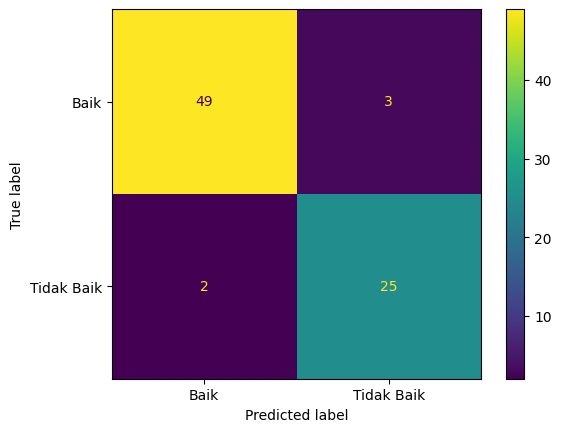

In [48]:
cm = confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le_y.classes_).plot()
plt.show()

In [49]:
print(classification_report(y_val, y_pred, target_names=le_y.classes_))

              precision    recall  f1-score   support

        Baik       0.96      0.94      0.95        52
  Tidak Baik       0.89      0.93      0.91        27

    accuracy                           0.94        79
   macro avg       0.93      0.93      0.93        79
weighted avg       0.94      0.94      0.94        79



REGRESI

In [50]:
# Regresi: prediksi nilai asli G3
y_reg = df['G3']

In [51]:
Xr_train, Xr_val, yr_train, yr_val = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)

In [52]:
model_reg = LinearRegression()
model_reg.fit(Xr_train, yr_train)

LinearRegression()

In [53]:
y_pred_reg = model_reg.predict(Xr_val)

In [54]:
y_pred_reg

array([ 6.28152491, 11.32691676,  3.03252133,  8.03726136,  8.55577788,
       12.36703933, 18.68481592,  7.54069216,  6.98823227, 12.36020452,
       14.90845762,  5.3836497 , 13.81895171, 11.97752152, 14.72716267,
        8.44027634,  6.30339136, 11.22326399, 14.8853422 ,  8.08078298,
       14.44822794, 16.49103733, 14.58041803,  5.40605189,  8.43892208,
       20.40654179, 10.51524958,  9.0988644 , 16.32450897, 11.12046755,
        9.34071548,  7.36677788, 14.95249766, 12.52176305,  5.84862031,
        4.73453253, -2.5737015 , 15.10149711, 12.06324101,  7.1157345 ,
        5.46610814, 10.17209369, 14.09202403,  6.86483257, 16.66202664,
        9.67238227, 12.08270686, 13.99554342, 11.81873867, 16.01896106,
       13.77565817, 14.41941157, 10.90376203,  7.47342869,  3.69379841,
       12.53687656, 10.37647263,  6.83870931, 15.20216325, 16.18444018,
       13.05404291,  7.91899614,  7.49885656,  4.04369135,  3.89174733,
       16.57283165,  7.77095413,  9.07811307,  8.88373397, 15.94

In [55]:
print("MSE:", mean_squared_error(yr_val, y_pred_reg))
print("R2 :", r2_score(yr_val, y_pred_reg))

MSE: 5.032394108866745
R2 : 0.7545777855043497
